# SMS Spam Classification Project

**Objective:** Build a simple, robust Machine Learning pipeline to classify SMS text messages into **Ham** (legitimate) or **Spam** (unwanted / promotional).

**Key Steps:**
1. **Load and Inspect Data:** Check row counts, missing values, duplicates.
2. **Exploratory Data Analysis (EDA):** Understand class balance and message length characteristics.
3. **Text Preprocessing:** Lowercasing, URL cleanup, and punctuation removal.
4. **Vectorization:** Convert words into numerical weights using **TF-IDF**.
5. **Model Training & Comparison:** Compare **Multinomial Naive Bayes** and **Logistic Regression**.
6. **Evaluation:** Check Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
7. **Deployment Pipeline:** Export trained model for the Streamlit web application.

### 1. Import Necessary Libraries

In [2]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Visual configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

### 2. Load the Dataset

In [3]:
df = pd.read_csv('sms_spam_collection (1).csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 5572 rows, 2 columns


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### 3. Data Cleaning & Encoding
Let's remove duplicate broadcast messages and encode our labels (`ham` -> `0`, `spam` -> `1`).

In [6]:
print(f"Duplicate records found: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

df['target'] = df['label'].map({'ham': 0, 'spam': 1})

print("\nClass counts:")
print(df['label'].value_counts())
print("\nClass proportions (%):")
print((df['label'].value_counts(normalize=True) * 100).round(2))

Duplicate records found: 403
Dataset shape after removing duplicates: (5169, 2)

Class counts:
label
ham     4516
spam     653
Name: count, dtype: int64

Class proportions (%):
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


### 4. Exploratory Data Analysis (EDA)
Let's see if message length differs significantly between legitimate and spam messages.

In [7]:
df['char_count'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

df.groupby('label')[['char_count', 'word_count']].mean().round(1)

0       111
1        29
2       155
3        49
4        61
       ... 
5164    160
5165     36
5166     57
5167    125
5168     26
Name: char_count, Length: 5169, dtype: int64


,char_count,word_count
label,,
ham,70.9,14.2
spam,137.7,23.7


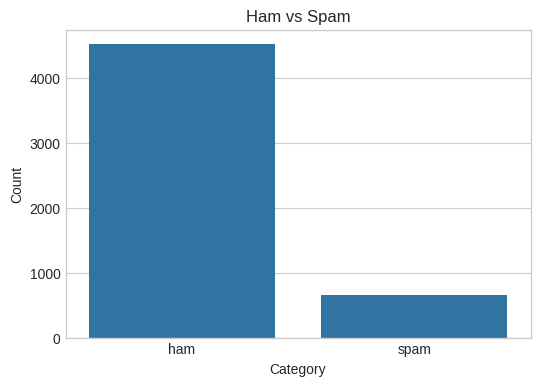

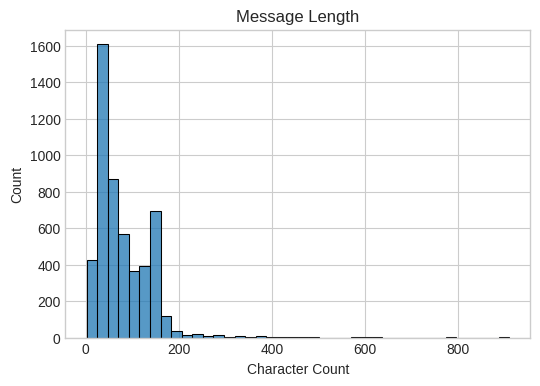

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Ham vs Spam')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(df['char_count'], bins=40)
plt.title('Message Length')
plt.xlabel('Character Count')
plt.ylabel('Count')
plt.show()

### 5. Text Preprocessing
A clean, simple function to lower text, remove URLs, remove digits, and strip punctuation.

In [9]:
def clean_text(text):
    text = text.lower()                                    # lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)                        # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()              # remove extra whitespace
    return text

sample_raw = df['message'].iloc[2]
print("Raw sample:", sample_raw)
print("Cleaned sample:", clean_text(sample_raw))

Raw sample: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned sample: free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply overs


In [11]:
df['cleaned_message'] = df['message'].apply(clean_text)

### 6. Train-Test Split & TF-IDF Vectorization
We use an 80/20 train/test split with stratification to preserve class balance.

In [12]:
X = df['cleaned_message']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 4135
Testing samples:  1034


In [14]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(X_train_vec)

print(f"TF-IDF Vocabulary size: {len(tfidf.vocabulary_)} features")

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 25903 stored elements and shape (4135, 3000)>
  Coords	Values
  (0, 1118)	0.6569750073800698
  (0, 166)	0.7539123554352702
  (1, 2986)	0.4098785053667981
  (1, 1064)	0.40345416392214883
  (1, 1543)	0.4145167294837267
  (1, 310)	0.5722981936404061
  (1, 729)	0.4121589583961541
  (2, 1811)	0.38918554882217743
  (2, 1751)	0.43112026970295086
  (2, 401)	0.6288480139907601
  (2, 2197)	0.5169333583152786
  (3, 212)	0.5268852637191642
  (3, 2741)	0.3509660329376654
  (3, 784)	0.633926236392655
  (3, 1421)	0.444243502386504
  (4, 1118)	0.37932251164365827
  (4, 2068)	0.6178699115277136
  (4, 2620)	0.5880146654676922
  (4, 483)	0.3585944196219454
  (5, 1421)	0.5200170240641682
  (5, 1505)	0.639977566295043
  (5, 1904)	0.565695155823806
  (6, 2966)	0.5490392641208267
  (6, 2516)	0.8357965580532508
  (7, 1118)	0.43170383159281484
  :	:
  (4129, 688)	0.40285139214732596
  (4129, 576)	0.46745466150146675
  (4129, 2467)	0.4423029267718421

### 7. Model Training & Comparison
We compare two models:
1. **Multinomial Naive Bayes** (the classic probabilistic spam detection algorithm)
2. **Logistic Regression** (standard linear classifier)

In [15]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_nb = nb_model.predict(X_test_vec)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_vec, y_train)
y_pred_lr = lr_model.predict(X_test_vec)

results = pd.DataFrame({
    'Model': ['Multinomial Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr)
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.9729,1.000,0.7863,0.8803
1,Logistic Regression,0.9536,0.977,0.6489,0.7798


### 8. Detailed Evaluation (Confusion Matrix)

=== Classification Report (Naive Bayes) ===

              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.98       903
    Spam (1)       1.00      0.79      0.88       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



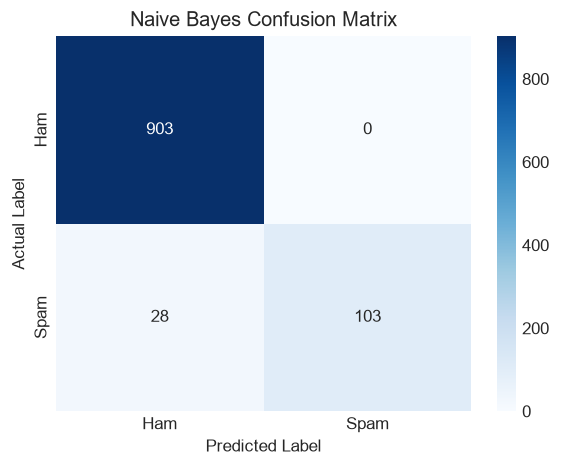

In [ ]:
# Classification Report
print("=== Classification Report (Naive Bayes) ===\n")
print(classification_report(y_test, y_pred_nb, target_names=['Ham (0)', 'Spam (1)']))

cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9. Test with Custom Real-World Messages

In [ ]:
# Real-world test examples
test_samples = [
    "Hey are we still meeting at the library at 5pm? Let me know.",
    "CONGRATULATIONS! You have won a $1,000 Walmart gift card! Claim now by calling 0800-12345.",
    "Your delivery package #4829 is scheduled for delivery today by 3 PM.",
    "URGENT: Your mobile account has been suspended! Text UPDATE to 89201 to restore service."
]

for msg in test_samples:
    cleaned = clean_text(msg)
    vec = tfidf.transform([cleaned])
    pred = nb_model.predict(vec)[0]
    prob = nb_model.predict_proba(vec)[0]
    tag = 'SPAM 🚨' if pred == 1 else 'HAM ✅'
    confidence = prob[pred] * 100
    print(f"[{tag}] ({confidence:.1f}% confidence)")
    print(f"  Message: \"{msg}\"\n")

[HAM ✅] (99.4% confidence)
  Message: "Hey are we still meeting at the library at 5pm? Let me know."

[SPAM 🚨] (84.8% confidence)
  Message: "CONGRATULATIONS! You have won a $1,000 Walmart gift card! Claim now by calling 0800-12345."

[HAM ✅] (59.8% confidence)
  Message: "Your delivery package #4829 is scheduled for delivery today by 3 PM."

[SPAM 🚨] (94.8% confidence)
  Message: "URGENT: Your mobile account has been suspended! Text UPDATE to 89201 to restore service."



### 10. Save the Production Pipeline for Streamlit
We bundle the vectorizer and classifier together into a single scikit-learn Pipeline and save it as `sms_spam_model.joblib`.

In [ ]:
export_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=3000)),
    ('nb', MultinomialNB())
])

export_pipeline.fit(df['message'], df['target'])


joblib.dump(export_pipeline, 'sms_spam_model.joblib')
print("Model pipeline saved as 'sms_spam_model.joblib' successfully!")

Model pipeline saved as 'sms_spam_model.joblib' successfully!
